# Molecular Bands and Source Compilation

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapter 7 produced a checked atomic line-opacity slab on its declared
compact teaching window. That slab demonstrated the exact catalog routes
without pretending that a 133-row subset was the full two-million-row
source. In a cool atmosphere, even the complete atomic source would not
end the opacity budget. Carbon and oxygen can bind into CO, titanium and
oxygen into TiO, and hydrogen and oxygen into water. One molecular species
can then absorb at thousands or millions of nearby wavelengths. If we
omit those transitions, broad combs of absorption are simply missing.

Why does one molecule produce so many lines? An atom already has
discrete electronic energies. A molecule has additional ways to
store energy: the nuclei can vibrate relative to one another and
the whole molecule can rotate. A useful first approximation is

\[
E \simeq E_{\rm electronic}
  +h\nu_{\rm vib}\left(v+\frac12\right)
  +B\,J(J+1).
\]

Here \(v=0,1,2,\ldots\) labels vibrational states, \(J=0,1,2,\ldots\)
labels rotational states, \(h\nu_{\rm vib}\) is an approximate
vibrational spacing, and \(B\) is a rotational constant in energy
units. One electronic or vibrational change can occur for many
populated rotational states. Their transition wavelengths gather
into a **band** rather than one isolated line.

<figure>
  <img src="assets/schematics/textbook/ch08-one-molecule-band-v1.png"
       alt="One molecule branches into electronic shelves with vibrational sublevels and rotational ticks; many allowed transitions become a cluster of absorption sticks called a molecular band.">
  <figcaption><strong>One population, many transitions.</strong>
  Electronic, vibrational, and rotational structure creates many
  nearby line centers from one molecular species. The level spacings
  and stick heights are conceptual.</figcaption>
</figure>

Real calculations do not derive millions of molecular transitions
from this approximate formula. Laboratory and theoretical source
lists supply the centers, strengths, isotope identities, lower-state
energies, and damping data. Unfortunately, those lists do not share
one storage convention. This chapter therefore asks:

> **How can unlike molecular sources become one checked opacity
> contribution without losing isotope weights, record order,
> population ownership, or the distinction between code that exists
> and physics that is actually wired into a runtime?**

The construction has two movements. First we translate text bands,
packed TiO, packed H\(_2\)O, and converted atmosphere records into
explicit common fields. Then we connect those fields to the
already-closed molecular populations and deposit their profiles
into a depth-by-wavelength opacity slab. We reuse the single-line
physics of Chapter 6 and the sparse addition of Chapter 7; neither
is derived a second time.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from book.chapter08_runtime import (
    atmosphere_family_checkpoint,
    cache_checkpoint,
    catalog_checkpoint,
    doppler_checkpoint,
    feature_status_rows,
    invariant_checkpoint,
    manifest_rug_checkpoint,
    molecular_opacity_checkpoint,
    packed_compiler_checkpoint,
    population_and_band_checkpoint,
    source_checkpoint,
    sparse_oracle_checkpoint,
    text_compiler_checkpoint,
    text_record_checkpoint,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel

def finish_plot(axes, *, xlabel, ylabel, title, ylog=False):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    if ylog:
        axes.set_yscale("log")
    add_quiet_grid(axes, axis="both" if ylog else "y")
    plt.show()
    plt.close(axes.figure)


> **Movement I — A common record from unlike molecular sources.**
> We begin on the host CPU, where discrete source meanings can be
> decoded once and checked exactly.

## 8.1 Millions of source rows, hundreds of teaching rows

Four words will recur in this movement.

- A **manifest** is an ordered list declaring which sources belong to
  a calculation.
- A **packed field** stores a physical meaning in a compact integer
  code rather than directly in physical units.
- **Memory mapping** lets an array on disk behave like an array
  without first copying the entire file into memory.
- A **compiler** translates a source representation into the smaller
  arrays needed by one wavelength window.

These ideas are necessary because the pinned sources are large:
32 text bands contain more than 22 million rows, TiO more than
37 million, H\(_2\)O more than 65 million, and the converted
atmosphere diatomic catalog more than 12 million. Copying all of
them into a teaching repository would hide the algorithm beneath
several gigabytes of data.

The book instead carries checksum-bound slices. Every retained
number is an original source value, and the builder records the
original row. The complete manifest remains present, so order and
full-source counts are still testable. This is enough to rebuild
every branch used here while keeping the normal book small and
self-contained.


In [3]:
sources = source_checkpoint()

print(f"manifest bands:          {sources.band_count}")
print(f"full text records:       {sources.full_text_record_count:,}")
print(f"full TiO records:        {sources.full_tio_record_count:,}")
print(f"full H2O records:        {sources.full_h2o_record_count:,}")
print(f"full diatomic records:   {sources.full_diatomic_record_count:,}")
print()
print(f"local text rows:         {sources.compact_text_record_count}")
print(f"local TiO rows:          {sources.compact_tio_record_count}")
print(f"local H2O rows:          {sources.compact_h2o_record_count}")
print(f"local diatomic rows:     {sources.compact_diatomic_record_count}")
print(f"verified local files:    {len(sources.local_hashes)}")


manifest bands:          32
full text records:       22,377,706
full TiO records:        37,744,499
full H2O records:        65,912,356
full diatomic records:   12,488,322

local text rows:         220
local TiO rows:          64
local H2O rows:          28
local diatomic rows:     96
verified local files:    7


The compact text archive contains all 32 band names. It retains
source-order anchors plus lines in two small windows: a mixed
molecular window near 499 nm for the opacity calculation and six
CO transitions near 1000 nm for a clean physical example. The TiO
file is one contiguous 64-record slice. The H\(_2\)O file combines
a contiguous local slice with four source-order sign anchors, because
all four isotope encodings do not occur in one tiny wavelength
interval.

## 8.2 One thermochemical population feeds many lower states

Chapter 4 solved how many molecules of each species exist. Its
public molecular lane is

\[
\texttt{partition_normalized_populations[:, 5, :]}
\quad [\mathrm{cm}^{-3}].
\]

“Partition normalized” is essential. For species \(s\), this array
contains \(n_s/U_s\): the total species population divided by its
molecular partition function. An individual line still supplies
its own lower-state excitation factor,

\[
\exp\!\left(-\widetilde E_l\frac{hc}{kT}\right),
\]

where \(\widetilde E_l=E_l/(hc)\) is stored in cm\(^{-1}\). We must
not divide by \(U_s\) again.

Molecular source codes map to the exact stage-5 column by

\[
p(s)=\left\lfloor\frac{s}{6}\right\rfloor-1.
\]

This is an implementation interface, not a new chemical notation.
H\(_2\), CO, TiO, and H\(_2\)O therefore use columns 39, 45, 60,
and 88. The plot below uses six actual CO records. Heights show the
compiled line-strength coefficient only; the shared CO population
will multiply every stick later.


H2  : species_code=240 -> column 39
CO  : species_code=276 -> column 45
TiO : species_code=366 -> column 60
H2O : species_code=534 -> column 88


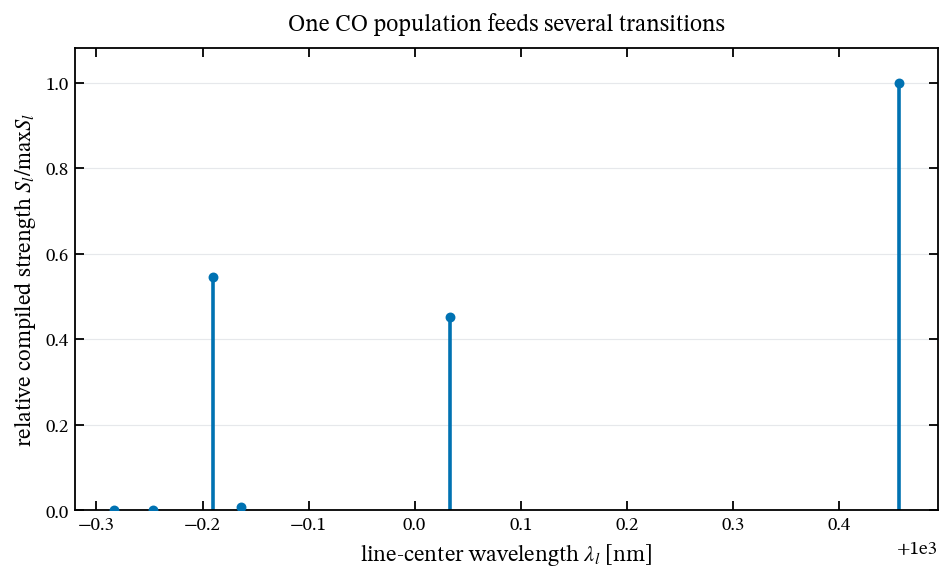

cool-state CO n/U range: 4.174e+07--4.055e+12 cm^-3


In [4]:
band = population_and_band_checkpoint()

for name, code_value, column in zip(
    band.molecule_names,
    band.species_code,
    band.population_column,
):
    print(f"{name:4s}: species_code={code_value:3d} -> column {column:2d}")

relative_strength = (
    band.co_classical_line_strength
    / band.co_classical_line_strength.max()
)
figure, axes = single_panel()
axes.vlines(
    band.co_wavelength_nm,
    0.0,
    relative_strength,
    color=PAPER_COLORS["blue"],
    linewidth=2.0,
)
axes.scatter(
    band.co_wavelength_nm,
    relative_strength,
    color=PAPER_COLORS["blue"],
    s=20,
    zorder=3,
)
axes.set_ylim(0.0, 1.08)
finish_plot(
    axes,
    xlabel=r"line-center wavelength $\lambda_l$ [nm]",
    ylabel=r"relative compiled strength $S_l/\max S_l$",
    title="One CO population feeds several transitions",
)

print(
    "cool-state CO n/U range: "
    f"{band.co_population_cm3.min():.3e}--"
    f"{band.co_population_cm3.max():.3e} cm^-3"
)


The six sticks are neither six CO abundances nor six independent
equilibrium solutions. They are six transitions drawing from one
depth-dependent \(n_{\rm CO}/U_{\rm CO}\). Each transition carries a
different \(S_l\) and \(\widetilde E_l\), so their final amplitudes
need not be equal.

## 8.3 A text row has fixed columns but two wavelength policies

The converted text archive came from fixed-width source records.
A **fixed-width** format assigns meaning by character position:
columns 0–9 hold the stored wavelength, 10–16 the logarithmic
oscillator strength, and later columns hold energies, a source code,
labels, isotope index, and radiative damping. The runtime reads the
converted arrays; it does not repeatedly parse raw text. Keeping the
parser is nevertheless valuable because it is an executable record
of what those columns meant.

The standard call prefers an energy-derived wavelength when the two
term energies differ:

\[
\lambda_{\rm energy}
  =\frac{10^7}
  {\left||\widetilde E_2|-|\widetilde E_1|\right|}
  \quad [\mathrm{nm}].
\]

If that difference is zero, the stored wavelength is the honest
fallback. Negative term energies mark predicted lines; the standard
call leaves them out. This is a source policy, not a claim that a
negative physical excitation exists.


In [5]:
record = text_record_checkpoint()
labels = (
    "stored wavelength",
    "log(gf)",
    "lower J",
    "first energy",
    "upper J",
    "second energy",
    "source code",
    "lower label",
    "upper label",
    "isotope",
    "radiative log",
)
for label, value in zip(labels, record.parsed_values):
    print(f"{label:20s}: {value}")

print()
print(f"stored wavelength:       {record.stored_wavelength_nm:.6f} nm")
print(f"energy wavelength:       {record.energy_wavelength_nm:.6f} nm")
print(f"zero-difference fallback:{record.fallback_wavelength_nm:10.6f} nm")
print(f"exact (608,12) dispatch: {record.pair_dispatch_species_code}")
print(f"code-only 608 fallback:  {record.code_fallback_species_code}")
print(f"fully unknown skipped:   {record.missing_dispatch_is_none}")


stored wavelength   : 1000.0
log(gf)             : -2.0
lower J             : 0.0
first energy        : 100.0
upper J             : 1.0
second energy       : 10100.0
source code         : 608
lower label         : LOW
upper label         : UP
isotope             : 12
radiative log       : 650

stored wavelength:       1000.000000 nm
energy wavelength:       1000.000000 nm
zero-difference fallback:1000.000000 nm
exact (608,12) dispatch: 276
code-only 608 fallback:  276
fully unknown skipped:   True


The dispatch result contains an important nuance. An exact
`(source_code, isotope_index)` pair wins. If that pair is absent,
a recognized source code may still select its declared principal
isotopologue. A row is skipped only when both the pair lookup and
the code-only lookup fail. Treating every unknown isotope pair as
automatically rejected would not reproduce the working compiler.

<figure>
  <img src="assets/schematics/textbook/ch08-encodings-to-record-v1.png"
       alt="Text-band, packed TiO, and signed H2O source records pass through separate decoders before converging on common center, strength, species, excitation, damping, and margin arrays.">
  <figcaption><strong>Common fields, family-owned meanings.</strong>
  The three sources retain distinct decoding and isotope conventions
  before they publish the same compiled array roles.</figcaption>
</figure>

## 8.4 First make the scalar compiler readable

For one accepted text row, compilation follows a short causal chain:

1. choose the stored or energy-derived wavelength;
2. enforce the requested window and its source-position guard;
3. dispatch the molecule and isotope weights;
4. turn logarithmic \(gf\) and isotope corrections into a linear
   oscillator strength;
5. locate the nearest geometric-grid center;
6. form the integrated strength and normalized damping fields.

The complete scalar helper performs those decisions in a plain
source-order `for` loop. It emits eight equal-length arrays:
`center_index_1based`, `classical_line_strength`, `species_code`,
`lower_excitation_cm`, three damping arrays, and `margin_class`.
The code cell below exposes the two branches that most often cause
silent disagreements before running the full scalar compiler.


In [6]:
def wavelength_from_terms(stored_nm, first_cm, second_cm):
    difference_cm = abs(abs(second_cm) - abs(first_cm))
    if difference_cm > 0.0:
        return 1.0e7 / difference_cm
    return abs(stored_nm)

def standard_text_row_is_eligible(stored_nm, first_cm, second_cm):
    if stored_nm == 0.0:
        return False
    return first_cm >= 0.0 and second_cm >= 0.0

assert wavelength_from_terms(1000.0, 100.0, 10100.0) == 1000.0
assert wavelength_from_terms(-999.0, 100.0, 100.0) == 999.0
assert not standard_text_row_is_eligible(1000.0, -100.0, 9900.0)

compiler = text_compiler_checkpoint()
print(f"scalar accepted rows:  {compiler.scalar_line_count}")
print("exact scalar output dtypes:")
for field, dtype in compiler.dtypes.items():
    print(f"  {field:28s} {dtype}")


scalar accepted rows:  93
exact scalar output dtypes:
  center_index_1based          int32
  classical_line_strength      float32
  species_code                 int16
  lower_excitation_cm          float32
  radiative_damping            float32
  stark_damping                float32
  van_der_waals_damping        float32
  margin_class                 int16


Notice what this cell did not do. It did not paste a production
parser into prose, and it did not hide wavelength choice behind a
high-level call. The small functions make the source policy
inspectable; the reusable scalar compiler then carries the same
decisions across every band.

## 8.5 Why the text compiler uses `njit` but not `prange`

Numba can translate a numerical Python loop to machine code.
`@numba.njit(cache=True)` means “compile without Python objects and
retain a compatible machine-code signature for later processes.”
It does **not** mean “cache the scientific output arrays.”

The production text kernel remains serial. It compacts accepted
rows into an ordered stream: rejecting row 5 changes the output
position of every later accepted row. Manifest order and source-row
order are part of the result, so no `parallel=True` or `prange` is
invented for symmetry.

This differs from the atmosphere selector. There, each source row
can independently produce one Boolean keep value. A `prange` loop
builds that mask, and the accepted rows are gathered in source order
afterwards. Later still, large molecular opacity blocks are Torch
operations on the selected device. Different dependencies deserve
different acceleration.


In [7]:
assert all(compiler.field_exact.values())
print("scalar vs serial cached-njit fields:")
for field, exact in compiler.field_exact.items():
    print(f"  {field:28s} exact={exact}")

print()
print(f"readable scalar loop:      {compiler.scalar_seconds:.4f} s")
print(f"first compiled call here:  {compiler.first_compiled_seconds:.4f} s")
print(f"compiled-value cache hit:  {compiler.compiled_cache_hit_seconds:.4f} s")
print()
print("The first timing may reuse an on-disk Numba signature.")
print("Timing is a performance observation; field equality is the proof.")


scalar vs serial cached-njit fields:
  center_index_1based          exact=True
  classical_line_strength      exact=True
  species_code                 exact=True
  lower_excitation_cm          exact=True
  radiative_damping            exact=True
  stark_damping                exact=True
  van_der_waals_damping        exact=True
  margin_class                 exact=True

readable scalar loop:      0.0065 s
first compiled call here:  0.0081 s
compiled-value cache hit:  0.0003 s

The first timing may reuse an on-disk Numba signature.
Timing is a performance observation; field equality is the proof.


The first compiled call in a fresh notebook process is not
automatically a “cold Numba compile”: `cache=True` may restore a
compatible machine-code signature from disk. The third timing is a
different cache again—the per-window scientific arrays. Naming the
cache is part of interpreting a benchmark.

## 8.6 Manifest order becomes catalog order

A fresh standard text build reads band names in the exact order of
`manifest["text_sources"]`. It compiles each band in source-row
order and concatenates the outputs in that same sequence. Wavelength
centers from different bands may overlap; the output is not globally
sorted by center.

The ordered-rug plot places manifest position on the vertical axis.
Only bands with an accepted compact-window row are shown. Moving
horizontally follows wavelength; moving vertically follows source
ownership. The plot is deliberately not a spectrum.


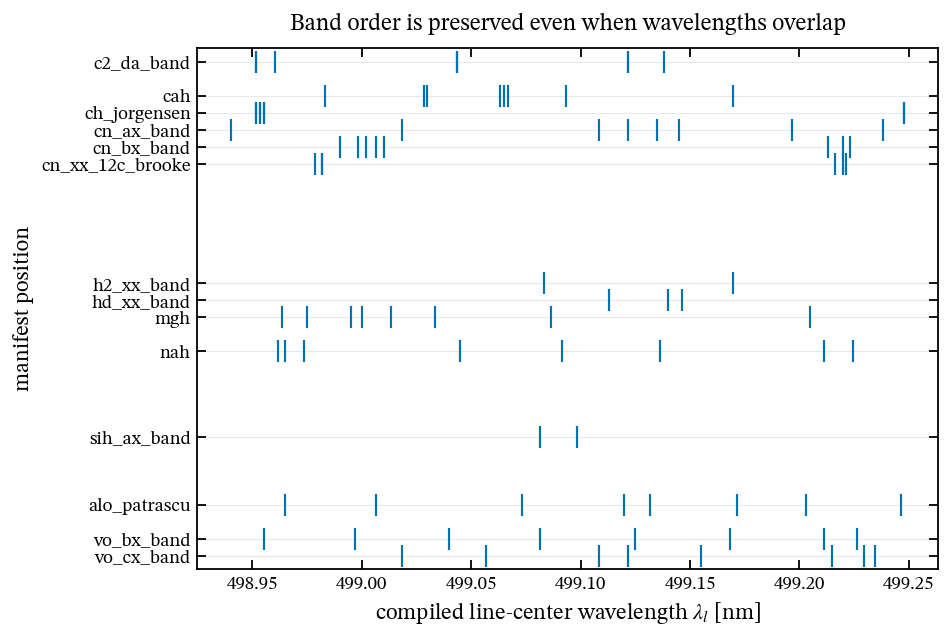

fresh per-band concatenation exact: True
 2  c2_da_band               8 rows
 4  cah                      8 rows
 5  ch_jorgensen             8 rows
 6  cn_ax_band               8 rows
 7  cn_bx_band               8 rows
 8  cn_xx_12c_brooke         6 rows
15  h2_xx_band               2 rows
16  hd_xx_band               3 rows
17  mgh                      8 rows
19  nah                      8 rows
24  sih_ax_band              2 rows
28  alo_patrascu             8 rows
30  vo_bx_band               8 rows
31  vo_cx_band               8 rows


In [8]:
rug = manifest_rug_checkpoint()
active = np.flatnonzero(rug.line_count_by_band > 0)

figure, axes = single_panel(height=4.8)
axes.scatter(
    rug.wavelength_nm,
    rug.manifest_index,
    marker="|",
    s=150,
    linewidths=1.2,
    color=PAPER_COLORS["blue"],
)
axes.set_yticks(active, [rug.band_name[index] for index in active])
axes.set_ylim(active[-1] + 0.8, active[0] - 0.8)
finish_plot(
    axes,
    xlabel=r"compiled line-center wavelength $\lambda_l$ [nm]",
    ylabel="manifest position",
    title="Band order is preserved even when wavelengths overlap",
)

print(f"fresh per-band concatenation exact: {rug.concatenation_exact}")
for index in active:
    print(
        f"{index:2d}  {rug.band_name[index]:22s} "
        f"{rug.line_count_by_band[index]:3d} rows"
    )


The alternating groups in the figure are not a physical layering of
molecules. They are reproducible source order. Changing that order
can change floating-point association later even though the set of
transitions is unchanged.

## 8.7 Packed TiO uses lookup indices and five isotope weights

A TiO record occupies 16 bytes. It stores a fine logarithmic
wavelength code, a packed isotope/species code, lower-energy and
oscillator-strength lookup indices, and three damping indices. The
source wavelength step is

\[
\Delta\ln\lambda=
  \ln\!\left(1+\frac{1}{2{,}000{,}000}\right),
\]

and the 32768-entry lookup table is

\[
T_i=10^{(i-16384)\,0.001}.
\]

Five source isotope codes carry fractions
\(0.0793, 0.0728, 0.7394, 0.0551,\) and \(0.0534\). They all map to
synthesis `species_code=366`; their isotope fractions belong in the
line strength, not in five different equilibrium populations.

One historical detail must remain visible. Text bands use the
strength coefficient \(0.026538/1.77245\), while packed TiO and
H\(_2\)O use the parity-pinned literal \(0.01502\). The two values
differ by about 0.32%. Publishing the same field name does not erase
a family-owned source convention.


In [9]:
packed = packed_compiler_checkpoint()

print("TiO isotope occurrences in the compact slice:")
for isotope in range(1, 6):
    count = np.count_nonzero(packed.tio_isotope_index == isotope)
    fraction = packed.tio_isotope_fraction[isotope - 1]
    print(f"  isotope {isotope}: {count:2d} rows, fraction={fraction:.4f}")

air_shift_pm = 1.0e3 * (
    packed.tio_air_wavelength_nm - packed.tio_vacuum_wavelength_nm
)
print(f"compiled TiO rows:       {packed.tio_line_count}")
print(
    "vacuum-to-air shift range: "
    f"{air_shift_pm.min():.3f}--{air_shift_pm.max():.3f} pm"
)
print(f"TiO fields changed by air flag: {packed.tio_air_changed_fields}")
print(f"text strength constant:  {packed.text_strength_coefficient:.12f}")
print(f"packed strength constant:{packed.packed_strength_coefficient:13.12f}")
print(
    "packed/text difference:   "
    f"{100.0 * packed.fractional_coefficient_difference:.6f}%"
)


TiO isotope occurrences in the compact slice:
  isotope 1: 12 rows, fraction=0.0793
  isotope 2: 17 rows, fraction=0.0728
  isotope 3: 21 rows, fraction=0.7394
  isotope 4:  3 rows, fraction=0.0551
  isotope 5: 11 rows, fraction=0.0534
compiled TiO rows:       64
vacuum-to-air shift range: -139.175---139.175 pm
TiO fields changed by air flag: ('center_index_1based', 'classical_line_strength', 'radiative_damping', 'stark_damping', 'van_der_waals_damping')
text strength constant:  0.014972495698
packed strength constant:0.015020000000
packed/text difference:   0.317277%


The public vacuum/air flag leaves isotope identity unchanged, but
it affects more than a label on the center. TiO uses the selected
wavelength to form frequency, so line strength and normalized
damping fields change consistently with the center. The standard
synthesis route chooses vacuum wavelengths.

## 8.8 H\(_2\)O hides four isotopologues in two signs

A packed water record is shorter: one wavelength code and two
signed 16-bit fields. The signs are storage codes, not negative
molecular energies. The exact tests use “positive” and
“nonpositive,” so a zero follows the nonpositive branch:

\[
\begin{array}{c|c|c}
\text{energy field} & \text{strength field} & \text{isotope index}\\
\hline
+ & + & 0\\
+ & \leq 0 & 1\\
\leq 0 & + & 2\\
\leq 0 & \leq 0 & 3
\end{array}
\]

The corresponding fractions are
\(0.9976, 0.0004, 0.0020,\) and \(0.00001\), and all four map to
`species_code=534`. The compiler takes absolute field values only
after the sign pair has selected the isotope.


In [10]:
print("H2O sign decoding in the compact source:")
for isotope, (label, fraction) in enumerate(
    zip(packed.h2o_sign_labels, packed.h2o_isotope_fraction)
):
    count = np.count_nonzero(packed.h2o_isotope_index == isotope)
    print(
        f"  {label:8s} -> isotope {isotope}, "
        f"fraction={fraction:.5f}, rows={count}"
    )

print()
print(f"H2O compiler output rows: {packed.h2o_line_count}")
print(f"H2O fields changed by air flag: {packed.h2o_air_changed_fields}")
print("This proves compiler availability, not standard synthesis wiring.")


H2O sign decoding in the compact source:
  +,+      -> isotope 0, fraction=0.99760, rows=25
  +,<=0    -> isotope 1, fraction=0.00040, rows=1
  <=0,+    -> isotope 2, fraction=0.00200, rows=1
  <=0,<=0  -> isotope 3, fraction=0.00001, rows=1

H2O compiler output rows: 28
H2O fields changed by air flag: ('center_index_1based', 'radiative_damping')
This proves compiler availability, not standard synthesis wiring.


H\(_2\)O uses vacuum frequency for its strength and Stark/van der
Waals normalization even when the optional air correction changes
the synthesis center. Its radiative rule uses the selected
wavelength. This field-by-field behavior is why the water format is
decoded on its own rather than squeezed through the TiO parser.

## 8.9 The atmosphere lane has its own converted families

The atmosphere solver reaches the same physical goal through
different source records.

- **Diatomic** records are four packed 32-bit words. A molecule/
  isotope lookup supplies a log-strength offset, and the Stark
  packed field is fixed to 1.
- **TiO** reuses 16-byte packed records. Five isotope offsets are
  applied, while the population slot and two damping fields receive
  exact family overrides.
- **Water** uses the two-sign decoder, atmosphere population row 939,
  four packed strength offsets, and a frequency-bin-dependent
  radiative field.
- **H\(_3^+\)** is a runtime-capable explicit-path branch. The
  standard source resolver supplies no H\(_3^+\) file.

After these corrections, all admitted rows become the
`SelectedLineCatalog` built in Chapter 7 and use its common opacity
deposition. There is no second secret “molecular profile.”

The selection below uses a deliberately permissive population ratio
and zero excitation suppression, so its purpose is to expose family
transformations—not to model a stellar atmosphere. The two-row
H\(_3^+\) file is explicitly a path-routing control copied from
source records; it is not a scientific H\(_3^+\) catalog.


In [11]:
atmosphere_families = atmosphere_family_checkpoint()

print("family                 source rows   admitted rows")
for name, source_count, selected_count in zip(
    atmosphere_families.family_names,
    atmosphere_families.source_count,
    atmosphere_families.selected_count,
):
    print(f"{name:22s} {source_count:11d} {selected_count:15d}")

print()
for family, offsets in atmosphere_families.offset_examples.items():
    print(f"{family:10s} packed log-offset examples: {offsets}")
print(
    "water packed species codes: "
    f"{atmosphere_families.water_packed_species}"
)
print(
    "H3+ probe is a scientific catalog: "
    f"{atmosphere_families.h3plus_probe_is_scientific_catalog}"
)


family                 source rows   admitted rows
diatomic                        96              96
TiO                             64              64
H2O                             28              28
H3+ path probe                   2               2

diatomic   packed log-offset examples: [   -2  -996  -996   -10   -10    -2   -35 -1960]
TiO        packed log-offset examples: [-1272 -1259 -1138 -1101  -131]
H2O        packed log-offset examples: [-5000 -3398 -2690    -1]
H3+        packed log-offset examples: [-1272]
water packed species codes: [-9403 -9402 -9401 -9400]
H3+ probe is a scientific catalog: False


## 8.10 Availability, default sources, and runtime wiring

Three statements that sound similar are logically different:

1. a compiler or selector exists;
2. a default source file is available;
3. the standard high-level runtime actually deposits that family.

The distinction matters most for water. Atmosphere synthesis of its
own opacity includes water by default. Spectral synthesis contains a
working `compile_h2o_partridge` function, but its standard molecular
builder concatenates only text bands followed by TiO. There is no
public flag that inserts water into that builder. Conversely,
H\(_3^+\) has an explicit-path atmosphere selector but no standard
resolver entry and no synthesis compiler route.

<figure>
  <img src="assets/schematics/textbook/ch08-two-lanes-v1.png"
       alt="The atmosphere lane uses standard diatomic, TiO, and H2O sources with an optional explicit H3+ path, while synthesis uses text bands and TiO; its H2O branch stops at compiler-only status and H3+ has no route.">
  <figcaption><strong>Availability is not wiring.</strong> Both lanes
  compute molecular line opacity, but their standard sources differ.
  The diagram is a conceptual status map, not an equality claim
  between intermediate arrays.</figcaption>
</figure>


In [12]:
statuses = feature_status_rows()
columns = (
    "family",
    "atmosphere_selector_exists",
    "atmosphere_default_source",
    "synthesis_compiler_exists",
    "synthesis_standard_deposits",
)
print(
    f"{'family':18s}  atm selector  atm default  "
    "syn compiler  syn deposits"
)
for row in statuses:
    print(
        f"{row['family']:18s}"
        f"{str(row['atmosphere_selector_exists']):>14s}"
        f"{str(row['atmosphere_default_source']):>13s}"
        f"{str(row['synthesis_compiler_exists']):>14s}"
        f"{str(row['synthesis_standard_deposits']):>14s}"
    )

assert [row["family"] for row in statuses] == [
    "text / diatomic", "TiO", "H2O", "H3+"
]


family              atm selector  atm default  syn compiler  syn deposits
text / diatomic             True         True          True          True
TiO                         True         True          True          True
H2O                         True         True          True         False
H3+                         True        False         False         False


The synthesis option `molecular_lines=True` is the standard default;
setting it false opts out of standard text/TiO compilation and
deposition. Atomic lines are controlled independently. A molecular
mass-table entry is likewise only metadata: the entry for
`species_code=504` supplies an H\(_3^+\) mass if a line ever reaches
the kernel, but it does not create a compiler or source route.

> **Movement II — From molecular populations to line opacity.**
> The source meanings are now fixed. We can build the exact arrays
> that a device kernel consumes.

## 8.11 Build a structure of arrays and derive indices once

Every standard synthesis compiler publishes the same eight output
arrays, but `MolecularLineCatalog` stores the seven physical fields;
`margin_class` remains compiler metadata. The catalog then derives

\[
\begin{aligned}
\texttt{center_index}
  &=\texttt{center_index_1based}-1,\\
\texttt{species_population_column}
  &=\texttt{species_code}//6-1,\\
\lambda_l
  &=\exp\!\left[
    (\texttt{center_index_1based}-1
     +\texttt{grid_origin_index})
    \texttt{log_grid_ratio}
  \right].
\end{aligned}
\]

This is a **structure of arrays**: millions of centers are contiguous
in one array, millions of strengths in another, and so on. It avoids
millions of Python line objects and makes each large device operation
regular.

The standard combined order is `[text, TiO]` for every field.
H\(_2\)O remains outside even though its compiler has already
succeeded.


In [13]:
catalog = catalog_checkpoint()

print(f"text lines:             {catalog.text_line_count}")
print(f"TiO lines:              {catalog.tio_line_count}")
print(f"combined lines:         {catalog.combined_line_count}")
print(f"first TiO row:          {catalog.first_tio_row}")
print(f"[text, TiO] exact:      {catalog.concatenation_exact}")
print(
    "center reconstruction max |delta lambda|: "
    f"{catalog.center_reconstruction_max_abs_nm:.3e} nm"
)
print()
print("unique species_code -> population column")
for code_value, column in zip(
    catalog.species_codes,
    catalog.species_population_columns,
):
    print(f"  {code_value:3d} -> {column:2d}")
print()
print("catalog fields:")
print("  " + ", ".join(catalog.combined_fields))


text lines:             93
TiO lines:              64
combined lines:         157
first TiO row:          93
[text, TiO] exact:      True
center reconstruction max |delta lambda|: 1.525e-05 nm

unique species_code -> population column
  240 -> 39
  246 -> 40
  264 -> 43
  270 -> 44
  300 -> 49
  312 -> 51
  324 -> 53
  342 -> 56
  366 -> 60
  372 -> 61
  492 -> 81

catalog fields:
  center_index_1based, classical_line_strength, species_code, lower_excitation_cm, radiative_damping, stark_damping, van_der_waals_damping, center_index, species_population_column, wavelength_nm, log_grid_ratio, grid_origin_index, unique_species_codes


Reconstructing line centers from the stored geometric-grid metadata
differs from their float32 catalog copy only at the expected final
cast. The integer center decisions were made once on the host.

## 8.12 A cache may save time; it may not become evidence

Several unrelated caches now exist:

- `cache=True` can retain Numba machine code;
- a per-source compiler cache can retain the eight window arrays;
- a combined cache can retain the standard text-plus-TiO product;
- a derived catalog cache can retain rebuilt indices.

Deleting any of them must change time, never physics. The test below
writes a compiled window to a disposable directory, lets the exact
catalog loader build its derived cache, reloads it, replaces it with
unreadable bytes, and verifies that the declared source arrays
rebuild the same catalog.

One limitation is recorded rather than concealed. A fresh text build
and its per-text cache include the manifest band order. The pinned
higher-level persistent combined-cache identity includes the text
archive, TiO source, window, grid resolution, wavelength policy, and
compiler name—but not `manifest.json` itself. A manifest-only edit
can therefore leave that cache apparently valid. We verify fresh
build order separately and do not claim a stronger invalidation
contract than the implementation provides.


In [14]:
cache = cache_checkpoint()

print(f"derived cache files:          {cache.cache_file_count}")
print(f"fresh source reload exact:    {cache.first_reload_exact}")
print(f"cache-hit reload exact:       {cache.cached_reload_exact}")
print(f"unreadable cache rebuilt:     {cache.corrupt_cache_rebuilt_exact}")
print(
    "combined cache fingerprints manifest: "
    f"{cache.combined_persistent_cache_fingerprints_manifest}"
)


derived cache files:          1
fresh source reload exact:    True
cache-hit reload exact:       True
unreadable cache rebuilt:     True
combined cache fingerprints manifest: False


A syntactically valid cache with matching metadata is trusted; the
runtime does not independently checksum every numerical member.
“Unreadable or identity-invalid caches rebuild” is therefore the
precise claim. A cache is acceleration, not a golden answer.

<figure>
  <img src="assets/schematics/textbook/ch08-host-to-device-v1.png"
       alt="Manifest and packed sources compile on the host, invariant arrays move once to a compute device, and bounded line chunks, surviving pairs, and wing blocks add into a depth-by-wavelength opacity slab.">
  <figcaption><strong>Bound the temporary arrays.</strong> Host
  compilation settles discrete source meanings. Resident invariants
  then feed separately bounded line, pair, and wing-offset work
  before sparse addition into the \((D,W)\) slab.</figcaption>
</figure>

## 8.13 Host decisions become device-resident invariants

`precompute_invariants` performs one-time host work: it reconstructs
centers, maps every line to a compact species inventory, computes
local grid resolving power in float64, and then uploads tensors.
Float64 differencing matters here because adjacent geometric-grid
wavelengths are extremely close.

The working device may be CUDA, Apple Metal, or CPU. Parsing JSON,
memory-mapping source files, running the Numba compiler, and deciding
discrete indices remain host tasks. The opacity accumulator is
float32 on every backend. CPU and CUDA use float64 for the
high-precision profile work; Metal uses float32 where float64 is not
supported. No `torch.compile` path is invented.


In [15]:
invariants = invariant_checkpoint()

print(f"{'field':32s} {'shape':18s} {'dtype':16s} device")
for field, shape, dtype, device in zip(
    invariants.field_names,
    invariants.shapes,
    invariants.dtypes,
    invariants.devices,
):
    print(f"{field:32s} {str(shape):18s} {dtype:16s} {device}")

print()
print(
    "local resolving power: "
    f"{invariants.local_resolving_power_min:.3f}--"
    f"{invariants.local_resolving_power_max:.3f}"
)


field                            shape              dtype            device
wavelength_grid                  (121,)             torch.float64    cpu
n_wavelengths                    ()                 int              host scalar
local_resolving_power            (121,)             torch.float64    cpu
classical_line_strength          (157,)             torch.float32    cpu
lower_excitation_cm              (157,)             torch.float64    cpu
radiative_damping                (157,)             torch.float32    cpu
stark_damping                    (157,)             torch.float32    cpu
van_der_waals_damping            (157,)             torch.float32    cpu
center_index                     (157,)             torch.int64      cpu
line_species_index               (157,)             torch.int64      cpu
line_wavelength_nm               (157,)             torch.float64    cpu
species_code                     (11,)              torch.int64      cpu
species_population_column        (11,)  

The table makes device residence concrete: long per-line arrays,
compact per-species arrays, the wavelength grid, and the Harris
profile tables now share one device. The Python dataclass remains a
small organizer; the expensive values are tensors.

## 8.14 Molecular mass sets one Doppler width per species and depth

A molecule of mass \(m_{\rm mol}\) has fractional Doppler width

\[
\frac{\Delta\nu_D}{\nu}
  =\frac{1}{c}
   \sqrt{\frac{2kT}{m_{\rm mol}}+\xi^2},
\]

where \(\xi\) is the microturbulent speed. The kernel receives
`microturbulence` as a depth column of shape `(D,)`. A public scalar
may be accepted earlier, but the structured-atmosphere bridge expands
it before this boundary.

For species \(s\), the reusable depth-dependent ratio is

\[
R_{d,s}
  =\frac{(n_s/U_s)_d}
  {\rho_d\,(\Delta\nu_D/\nu)_{d,s}}.
\]

This isolates the quantities shared by every transition of the same
molecule. Nonpositive population, density, or width returns zero
instead of an invalid division. An unlisted species uses the exact
conservative mass default of 20 amu.


In [16]:
doppler = doppler_checkpoint()
depth_index = 0

print(
    f"{'code':>4s} {'column':>7s} {'mass [amu]':>11s} "
    f"{'Doppler fraction':>18s} {'population ratio':>18s}"
)
for index, code_value in enumerate(doppler.species_code):
    print(
        f"{code_value:4d} "
        f"{doppler.population_column[index]:7d} "
        f"{doppler.species_mass_amu[index]:11.1f} "
        f"{doppler.doppler_fraction[depth_index, index]:18.6e} "
        f"{doppler.population_doppler_ratio[depth_index, index]:18.6e}"
    )

print()
print(
    "zero-microturbulence heavier molecule is narrower: "
    f"{doppler.thermal_width_heavier_is_smaller}"
)
print(
    "large-microturbulence mass widths converge:       "
    f"{doppler.microturbulent_widths_converge}"
)


code  column  mass [amu]   Doppler fraction   population ratio
 240      39         2.0       1.742230e-05       1.667130e+25
 246      40        13.0       9.184598e-06       6.922573e+13
 264      43        24.0       8.129691e-06       2.178480e+08
 270      44        26.0       8.026919e-06       2.264148e+14
 300      49        25.0       8.076412e-06       1.811496e+15
 312      51        29.0       7.897479e-06       7.478120e+16
 324      53        43.0       7.520235e-06       2.172763e+14
 342      56        41.0       7.559209e-06       5.988246e+13
 366      60        64.0       7.252634e-06       1.818488e+15
 372      61        67.0       7.227604e-06       1.799958e+13
 492      81        24.0       8.129691e-06       6.905279e+12

zero-microturbulence heavier molecule is narrower: True
large-microturbulence mass widths converge:       True


The production state does not use zero or enormous
microturbulence; those are limiting-case checks. They reveal which
term owns the width. At \(\xi=0\), thermal motion remembers molecular
mass. When \(\xi^2\) dominates, the mass distinction becomes small.

## 8.15 Live cutoffs and three different memory bounds

Source compilation answers “could this record belong to the
window?” The runtime must still ask, at every depth, “can this line
beat the local continuum floor?” It forms

\[
A^{(0)}_{d,l}=S_lR_{d,s(l)},\qquad
A_{d,l}=A^{(0)}_{d,l}
  \exp[-\widetilde E_l(hc/kT)_d],
\]

and compares both pre-excitation and final amplitudes with
`LINE_CENTER_CUTOFF_RATIO * continuum_opacity` at the clamped
center. Positive population ratio, Doppler width, wavelength, and
nonnegative raw damping are also required. These are live
depth-line decisions, not a second source compiler.

One chunk size cannot bound every temporary:

- `CHUNK_LINES = 500_000` bounds dense `(depth, line)` cutoff work;
- `PAIR_CHUNK = 200_000` bounds flattened surviving depth-line pairs;
- blocks of 256 integer offsets bound `(pair, wing offset)` work.

The Python loop chooses bounded blocks. Torch evaluates the large
algebra and scatter-add on the resident device. A small scalar read
may terminate a bounded wing walk; “device resident” never meant
that Python ceased to control the algorithm.

To check sparse addition, we take two real compact lines whose
centers land on the same pixel. A deliberately tiny dense oracle
evaluates each line separately, keeps the temporary line axis, and
sums it. The production path evaluates both together without that
permanent axis.


In [17]:
from payne_zero_synthesis.molecular_lines import CHUNK_LINES, PAIR_CHUNK

oracle = sparse_oracle_checkpoint()
depth_count = oracle.sparse_sum.shape[0]
wavelength_count = oracle.sparse_sum.shape[1]

print(f"CHUNK_LINES:                  {CHUNK_LINES:,}")
print(f"PAIR_CHUNK:                   {PAIR_CHUNK:,}")
print("wing-offset block:            256")
print(
    "example dense cutoff shape:    "
    f"({depth_count}, {min(CHUNK_LINES, catalog.combined_line_count)})"
)
print(
    "same-center source indices:     "
    f"{oracle.center_index_1based.tolist()}"
)
print(f"collision pixel (zero based): {oracle.collision_pixel}")
print(
    "dense-line-axis vs sparse max |difference|: "
    f"{oracle.maximum_absolute_difference:.3e}"
)
print(
    "dense-line-axis vs sparse max relative:     "
    f"{oracle.maximum_relative_difference:.3e}"
)


CHUNK_LINES:                  500,000
PAIR_CHUNK:                   200,000
wing-offset block:            256
example dense cutoff shape:    (6, 157)
same-center source indices:     [2, 2]
collision pixel (zero based): 1
dense-line-axis vs sparse max |difference|: 0.000e+00
dense-line-axis vs sparse max relative:     0.000e+00


Zero difference in this two-line control establishes the collision
semantics: contributions add; neither overwrites the other. The
complete runtime then deposits the center, walks the near wing to
ten Doppler widths, switches between the established Harris and
broad-Voigt routes, and continues an inverse-square far wing only
when it remains above the continuum-relative floor. Those profile
equations were earned in Chapters 6–7; the molecular additions are
source compilation, species population columns, and molecular
masses.

## 8.16 Form the molecular opacity slab and apply stimulation once

`accumulate_molecular(..., apply_stim=True)` completes every
line chunk in one shared float32 accumulator and then multiplies by

\[
1-\exp\!\left(-\frac{h\nu}{kT}\right).
\]

The factor is applied once after text and TiO have accumulated. The
plot shows one depth of the cool teaching state. A logarithmic axis
is necessary because the compact TiO contribution is much smaller
than the strongest text-band opacity in this narrow window; zeros
are omitted rather than assigned an artificial logarithm.


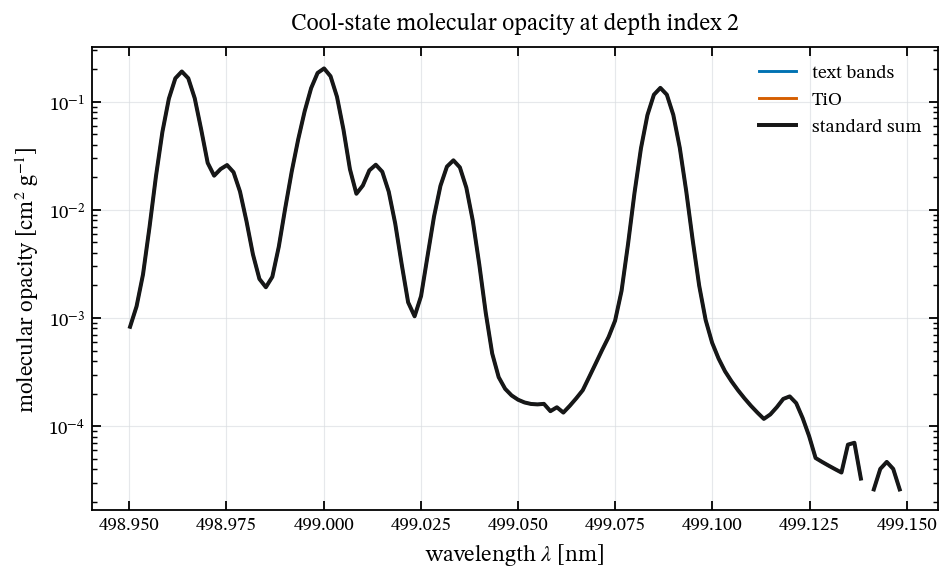

text + TiO vs combined max |difference|: 1.490e-08
chunk regrouping max |difference|:        5.960e-08
once-only stimulation max |difference|:   0.000e+00


In [18]:
opacity = molecular_opacity_checkpoint()
depth_index = opacity.depth_index

figure, axes = single_panel()
curves = (
    ("text bands", opacity.text_opacity[depth_index], PAPER_COLORS["blue"]),
    ("TiO", opacity.tio_opacity[depth_index], PAPER_COLORS["orange"]),
    ("standard sum", opacity.combined_opacity[depth_index], PAPER_COLORS["black"]),
)
for label, values, color in curves:
    axes.plot(
        opacity.wavelength_nm,
        np.where(values > 0.0, values, np.nan),
        label=label,
        color=color,
        linewidth=2.2 if label == "standard sum" else 1.6,
    )
axes.legend()
finish_plot(
    axes,
    xlabel=r"wavelength $\lambda$ [nm]",
    ylabel=r"molecular opacity [cm$^2$ g$^{-1}$]",
    title=f"Cool-state molecular opacity at depth index {depth_index}",
    ylog=True,
)

print(
    "text + TiO vs combined max |difference|: "
    f"{opacity.separate_sum_max_abs:.3e}"
)
print(
    "chunk regrouping max |difference|:        "
    f"{opacity.chunk_regrouping_max_abs:.3e}"
)
print(
    "once-only stimulation max |difference|:   "
    f"{opacity.stimulation_ratio_max_abs:.3e}"
)


Separate text and TiO calls perform two float32 accumulations and
one later addition; the combined call follows the standard
concatenation and one accumulator. Their tiny difference is a
measured association effect, not missing physics. Likewise,
changing a safe line-chunk size can regroup float32 additions. Exact
parity claims therefore name the standard order and chunk policy.

## 8.17 Population scaling and the final two-lane checkpoint

Before radiative transfer, line opacity is linear in the supplied
molecular population as long as the same lines remain above the live
cutoff. We scale the complete stage-5 molecular lane while holding
temperature, density, continuum opacity, catalog, and grid fixed.
The reference line passes through the origin with the nominal
integrated-opacity slope.


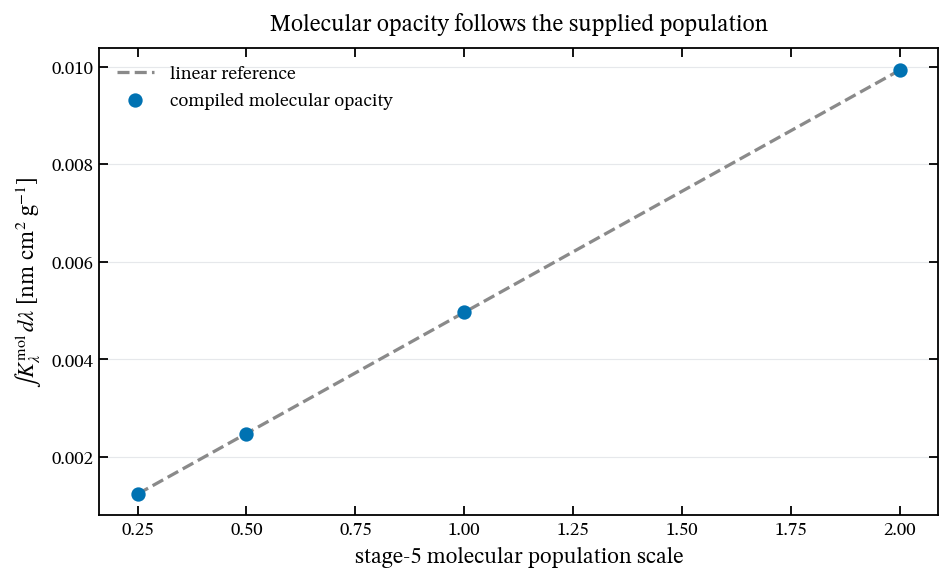

maximum departure from linear reference: 3.031e-03

final synthesis source boundary:
  standard text rows deposited: 93
  standard TiO rows deposited:  64
  compiler-only H2O rows:       28
  standard H2O rows deposited:  0
  synthesis H3+ route:           absent

final atmosphere source boundary:
  standard: diatomic + TiO + H2O
  optional: H3+ only through an explicit existing path


In [19]:
nominal_index = int(np.flatnonzero(opacity.population_scale == 1.0)[0])
linear_reference = (
    opacity.integrated_opacity[nominal_index]
    * opacity.population_scale
)

figure, axes = single_panel()
axes.plot(
    opacity.population_scale,
    linear_reference,
    color=PAPER_COLORS["grey"],
    linestyle="--",
    label="linear reference",
)
axes.scatter(
    opacity.population_scale,
    opacity.integrated_opacity,
    color=PAPER_COLORS["blue"],
    s=48,
    label="compiled molecular opacity",
    zorder=3,
)
axes.legend()
finish_plot(
    axes,
    xlabel="stage-5 molecular population scale",
    ylabel=r"$\int K^{\rm mol}_\lambda\,d\lambda$ [nm cm$^2$ g$^{-1}$]",
    title="Molecular opacity follows the supplied population",
)

relative_to_linear = (
    opacity.integrated_opacity / linear_reference - 1.0
)
print(
    "maximum departure from linear reference: "
    f"{np.max(np.abs(relative_to_linear)):.3e}"
)
print()
print("final synthesis source boundary:")
print(f"  standard text rows deposited: {catalog.text_line_count}")
print(f"  standard TiO rows deposited:  {catalog.tio_line_count}")
print(f"  compiler-only H2O rows:       {opacity.compiler_only_h2o_line_count}")
print(f"  standard H2O rows deposited:  {opacity.standard_h2o_line_count}")
print("  synthesis H3+ route:           absent")
print()
print("final atmosphere source boundary:")
print("  standard: diatomic + TiO + H2O")
print("  optional: H3+ only through an explicit existing path")


The small departure from a perfect line, if any, is informative:
changing population can move a marginal depth-line pair across the
continuum-relative cutoff, while surviving line amplitudes remain
linear. Nothing here is saturation; saturation appears only after
transfer converts opacity into escaping radiation.

The chapter ends with two lane-specific products:

\[
\begin{array}{ll}
\text{atmosphere:}&
  \text{standard diatomic + TiO + H}_2\text{O,}\\
  &\text{plus H}_3^+\text{ only for an explicit path};\\[3pt]
\text{synthesis:}&
  \text{default-on text bands + TiO device opacity,}\\
  &\text{with H}_2\text{O compiler-only and H}_3^+\text{ absent}.
\end{array}
\]

Both are molecular line-opacity implementations. Their source
policies and intermediate arrays are not identical, so each lane
must be checked against its own declared authority.

## 8.18 Chapter summary

1. Molecular bands arise because electronic states contain
   vibrational and rotational substructure; one species population
   can therefore feed many transitions.
2. Chapter 4 owns \(n_s/U_s\). Each molecular line supplies its own
   lower-state Boltzmann factor, strength, center, and profile
   without repeating equilibrium or partition normalization.
3. Text bands, packed TiO, packed H\(_2\)O, and atmosphere converted
   families retain different isotope, wavelength, and strength
   conventions before reaching common array roles.
4. The text compiler is a serial cached-Numba compactor because
   emitted record order is part of the result. Independent
   atmosphere keep masks may use `prange`.
5. Host compilation fixes discrete meanings and builds reusable
   invariants. Separately bounded line, pair, and wing-offset blocks
   then scatter-add into a float32 \((D,W)\) opacity slab.
6. A compiler's existence is not runtime wiring: atmosphere water is
   standard, atmosphere H\(_3^+\) is explicit-path only, synthesis
   text/TiO are standard, synthesis water is compiler-only, and
   synthesis H\(_3^+\) is absent.
7. The result is checked molecular mass absorption at every depth
   and wavelength of the declared compact window. It is not yet
   emergent intensity or flux.

### Next: Which photons actually escape?

We can now assemble continuous opacity, atomic forests, special
atomic profiles, and molecular bands into prepared depth-by-wavelength
arrays; the compact chapters have checked each physical route without
claiming full-catalog execution. Those arrays tell us how strongly
matter absorbs or redirects radiation, but not how much light escapes
through the overlying layers. [Chapter 9 follows radiation through that
ordered depth structure and turns prepared total and continuum opacity
into flux.](/reader.html?ch=9)
